## Analysing the Neural Network including FS, RS and IMP neurons.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In this notebook we analyse the neural network simulation (saved in *simulation_results*) which was obtained running the notebook *NN_FS_RS.ipynb*.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os
import h5py

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Plots_helper import *
from utils.Sim_helper import *

In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 


### Importing the spike data (.h5 file)

In [5]:
simulation_folder = 'simulations'
folder_name = 'test_0'

fig_name = 'Analysing_' + str(simulation_folder)

In [6]:
data = load_spike_data(os.path.join(simulation_folder, folder_name, "spikes_data.h5"))

In [7]:
data

{'network_composition': {'conn_prob': 0.05,
  'num_FS_neurons': 2000,
  'num_RS_neurons': 8000},
 'external_input': {'exc_input_FS_freq_Hz': 5.0,
  'exc_input_FS_time_s': array([1., 2.]),
  'exc_input_RS_freq_Hz': 3.0,
  'exc_input_RS_time_s': array([3., 4.]),
  'inh_input_FS_freq_Hz': 10.0,
  'inh_input_FS_time_s': array([5., 6.]),
  'inh_input_RS_freq_Hz': 30.0,
  'inh_input_RS_time_s': array([7., 8.])},
 'sim_duration': 10.0,
 'spikes': {'FS': {'i': array([  64, 1715, 1943, ...,  751,  258, 1713], dtype=int32),
   't': array([0.4795, 1.0036, 1.0038, ..., 4.0111, 4.0172, 4.8778])},
  'RS': {'i': array([1662, 2502, 5242, ..., 5227, 5294,   77], dtype=int32),
   't': array([0.3146, 0.4969, 2.4665, ..., 9.793 , 9.9099, 9.9312])}}}

In [8]:
exc_interval_FS = [data['external_input']['exc_input_FS_time_s'][0],data['external_input']['exc_input_FS_time_s'][1], 'FS']
exc_interval_RS = [data['external_input']['exc_input_RS_time_s'][0],data['external_input']['exc_input_RS_time_s'][1], 'RS']

inh_interval_FS = [data['external_input']['inh_input_FS_time_s'][0],data['external_input']['inh_input_FS_time_s'][1], 'FS']
inh_interval_RS = [data['external_input']['inh_input_RS_time_s'][0],data['external_input']['inh_input_RS_time_s'][1], 'RS']

In [9]:
exc_intervals = [exc_interval_FS, exc_interval_RS]
inh_intervals = [inh_interval_FS, inh_interval_RS]

### Plotting

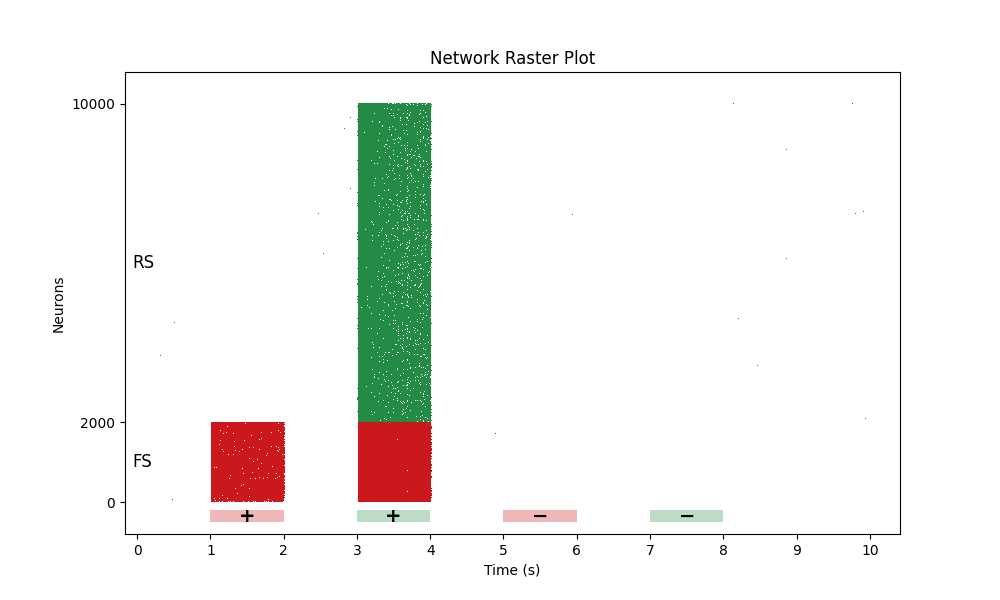

In [10]:
fig = network_raster_plot_h5(pop1 = data['spikes']['FS'], 
                    pop2 = data['spikes']['RS'], 
                    N_pop1 = data['network_composition']['num_FS_neurons'],
                    N_pop2 = data['network_composition']['num_RS_neurons'],
                    exc_intervals=exc_intervals,
                    inh_intervals=inh_intervals)

figs.append(fig)

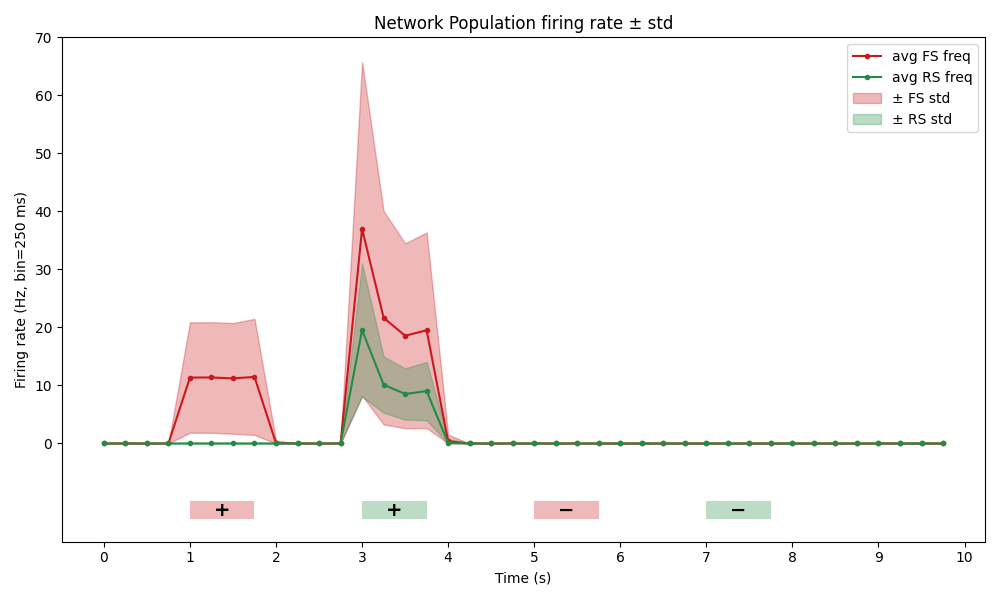

In [11]:
fig = plotting_pop_freq_and_std_h5(sim_duration =  data["sim_duration"] * b2.second, 
                              pop1 = data['spikes']['FS'], 
                              pop2 = data['spikes']['RS'], 
                              N_pop1 = data['network_composition']['num_FS_neurons'],
                              N_pop2 = data['network_composition']['num_RS_neurons'],
                              bin_size = 250 * b2.ms,
                              exc_intervals=exc_intervals,
                              inh_intervals=inh_intervals)
figs.append(fig)

In [12]:
save_figs(fig_path, fig_name, figs)